# 1. EDA

В ноутбуке проводится разведочный анализ датасета с молекулярными дескрипторами химических соединений.
Основные целевые показатели:

- **IC50, mM** - концентрация вещества, при которой наблюдается подавление биологической активности на 50%. Чем меньше IC50, тем выше активность вещества.
- **CC50, mM** - концентрация вещества, при которой наблюдается гибель 50% клеток. Чем выше CC50, тем ниже токсичность.
- **SI** - индекс селективности. Обычно рассчитывается как отношение CC50 к IC50. Чем выше SI, тем перспективнее соединение с точки зрения соотношения токсичности и активности.

In [1]:
# Подключение библиотек

from pathlib import Path
import json
import warnings


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

random_state = 42
target_columns = ["IC50, mM", "CC50, mM", "SI"]

data_path = Path("/Users/dmitrijgoncarov/mephi_masters/sem_2/classic_ML/coursework/drug_activity_prediction_variant/notebooks/coursework_dataset.csv")
results_dir = Path("/Users/dmitrijgoncarov/mephi_masters/sem_2/classic_ML/coursework/drug_activity_prediction_variant/notebooks/results")
figures_dir = results_dir / "figures"
tables_dir = results_dir / "tables"
figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)


In [2]:
# Загрузка данных

dataset = pd.read_csv(data_path)
dataset = dataset.drop(columns=[column for column in dataset.columns if str(column).startswith("Unnamed")], errors="ignore")
dataset = dataset.apply(pd.to_numeric, errors="coerce")
dataset = dataset.drop_duplicates()
dataset = dataset.dropna(subset=target_columns).reset_index(drop=True)

print("Размер датасета после базовой очистки:", dataset.shape)
print(dataset.head())


Размер датасета после базовой очистки: (969, 213)
     IC50, mM    CC50, mM         SI  MaxAbsEStateIndex  MaxEStateIndex  \
0    6.239374  175.482382  28.125000           5.094096        5.094096   
1    0.771831    5.402819   7.000000           3.961417        3.961417   
2  223.808778  161.142320   0.720000           2.627117        2.627117   
3    1.705624  107.855654  63.235294           5.097360        5.097360   
4  107.131532  139.270991   1.300000           5.150510        5.150510   

   MinAbsEStateIndex  MinEStateIndex       qed        SPS    MolWt  ...  \
0           0.387225        0.387225  0.417362  42.928571  384.652  ...   
1           0.533868        0.533868  0.462473  45.214286  388.684  ...   
2           0.543231        0.543231  0.260923  42.187500  446.808  ...   
3           0.390603        0.390603  0.377846  41.862069  398.679  ...   
4           0.270476        0.270476  0.429038  36.514286  466.713  ...   

   fr_sulfide  fr_sulfonamd  fr_sulfone  fr_term

После удаления технического индексного столбца и дубликатов в датасете остается 969 наблюдений и 213 числовых столбцов.
Из них 3 столбца являются целевыми показателями, остальные используются как молекулярные дескрипторы.
Объем выборки небольшой для большого числа признаков, поэтому при дальнейшем моделировании важно использовать регуляризацию, кросс-валидацию и аккуратную обработку пропусков.

In [3]:
# Общая структура датасета

print("Количество строк и столбцов:", dataset.shape)
print("Количество пропусков:", int(dataset.isna().sum().sum()))
print("Количество дубликатов:", int(dataset.duplicated().sum()))
dataset.info()


Количество строк и столбцов: (969, 213)
Количество пропусков: 36
Количество дубликатов: 0
<class 'pandas.DataFrame'>
RangeIndex: 969 entries, 0 to 968
Columns: 213 entries, IC50, mM to fr_urea
dtypes: float64(107), int64(106)
memory usage: 1.6 MB


In [4]:
# Описательная статистика целевых показателей

target_summary = dataset[target_columns].describe().T
target_summary["median"] = dataset[target_columns].median()
target_summary["skew"] = dataset[target_columns].skew()
target_summary["missing"] = dataset[target_columns].isna().sum()

target_summary_path = tables_dir / "eda_target_summary.csv"
target_summary.to_csv(target_summary_path)

print(target_summary)
print("Таблица сохранена:", target_summary_path)


          count        mean         std       min        25%         50%  \
IC50, mM  969.0  220.726223  397.172441  0.003517  12.515396   45.338355   
CC50, mM  969.0  586.419908  633.624464  0.700808  99.999345  424.166213   
SI        969.0   73.967907  695.564665  0.011489   1.488095    3.900000   

                 75%           max      median       skew  missing  
IC50, mM  231.373089   4128.529377   45.338355   3.757993        0  
CC50, mM  891.776925   4538.976189  424.166213   1.996707        0  
SI         16.375000  15620.600000    3.900000  17.728174        0  
Таблица сохранена: /Users/dmitrijgoncarov/mephi_masters/sem_2/classic_ML/coursework/drug_activity_prediction_variant/notebooks/results/tables/eda_target_summary.csv


Все целевые показатели имеют заметную асимметрию: среднее значение существенно больше медианы.
Особенно выраженная асимметрия наблюдается у SI, где медиана равна примерно 3.9, а максимум превышает 15000.
Это означает, что модели регрессии будут чувствительны к редким экстремальным значениям.
Поэтому далее для регрессионных моделей применяется логарифмическое преобразование целевой переменной.

In [5]:
# Проверка пропусков по признакам

missing_values = (
    dataset.isna()
    .sum()
    .sort_values(ascending=False)
    .rename("missing_count")
    .reset_index()
    .rename(columns={"index": "feature"})
)
missing_values = missing_values[missing_values["missing_count"] > 0]

print(missing_values.head(20))
print("Количество признаков с пропусками:", missing_values.shape[0])


                feature  missing_count
0           BCUT2D_MRHI              3
1           BCUT2D_MWHI              3
2          BCUT2D_CHGHI              3
3   MinAbsPartialCharge              3
4   MaxAbsPartialCharge              3
5      MinPartialCharge              3
6      MaxPartialCharge              3
7          BCUT2D_CHGLO              3
8         BCUT2D_LOGPHI              3
9        BCUT2D_LOGPLOW              3
10         BCUT2D_MWLOW              3
11         BCUT2D_MRLOW              3
Количество признаков с пропусками: 12


Пропусков немного относительно общего размера таблицы. Удалять строки или признаки из-за них нецелесообразно:
при 969 наблюдениях потеря строк может ухудшить устойчивость моделей.
В задачах моделирования пропуски заполняются медианой, чтобы статистика заполнения рассчитывалась только по обучающей выборке.

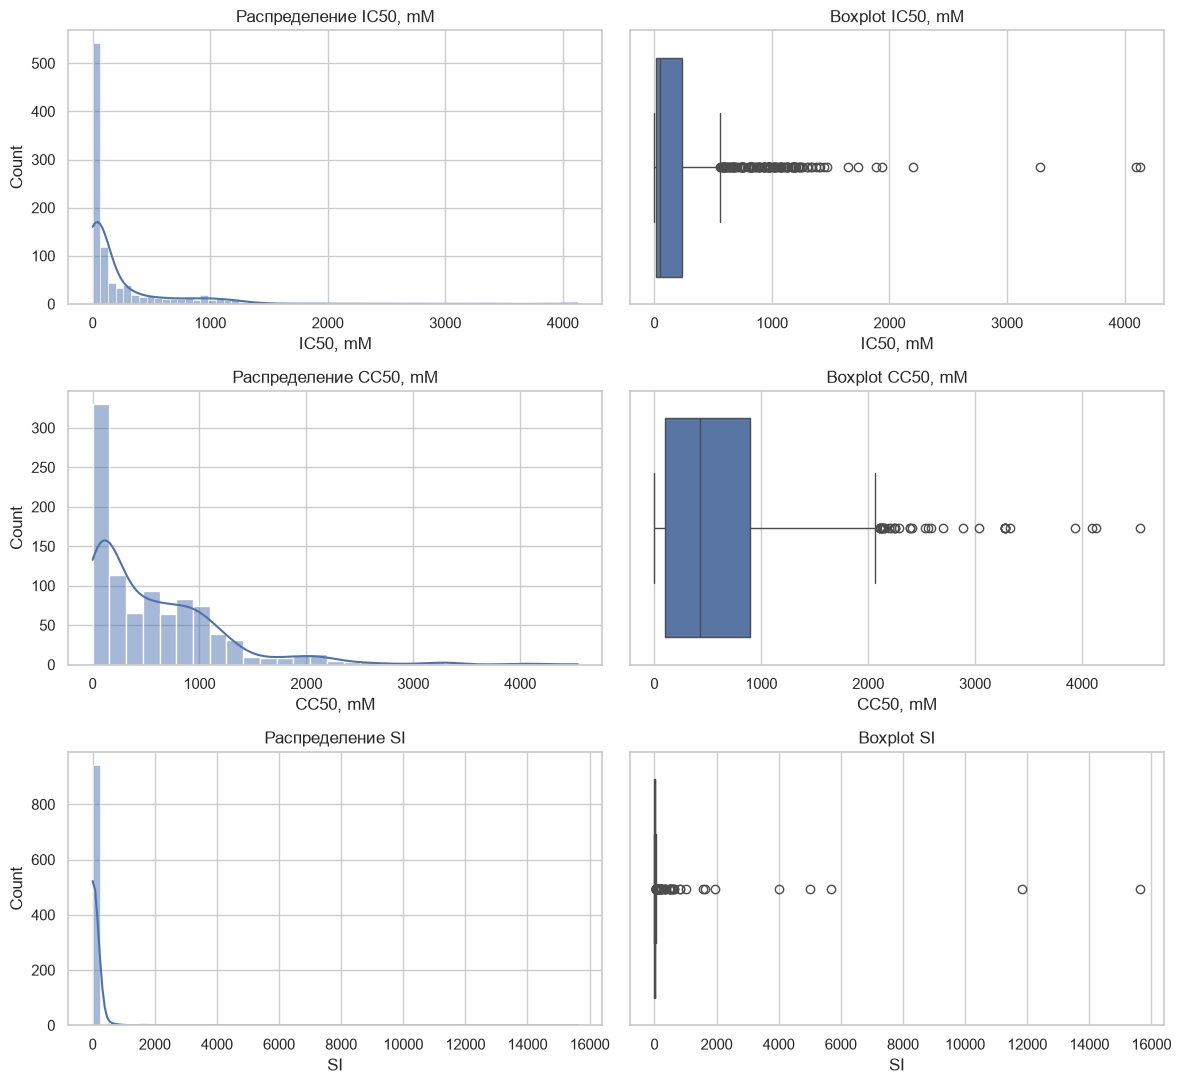

График сохранен: /Users/dmitrijgoncarov/mephi_masters/sem_2/classic_ML/coursework/drug_activity_prediction_variant/notebooks/results/figures/eda_target_distributions.png


In [6]:
# Визуализация распределений целевых показателей

figure, axes = plt.subplots(3, 2, figsize=(12, 11))

for row_index, target_column in enumerate(target_columns):
    sns.histplot(dataset[target_column], kde=True, ax=axes[row_index, 0])
    axes[row_index, 0].set_title(f"Распределение {target_column}")

    sns.boxplot(x=dataset[target_column], ax=axes[row_index, 1])
    axes[row_index, 1].set_title(f"Boxplot {target_column}")

plt.tight_layout()
distribution_path = figures_dir / "eda_target_distributions.png"
plt.savefig(distribution_path, dpi=160)
plt.show()

print("График сохранен:", distribution_path)


Гистограммы и boxplot подтверждают наличие длинных правых хвостов и выбросов.
Для IC50 и CC50 выбросы связаны с соединениями, которым требуется высокая концентрация для биологического эффекта или токсического действия.
Для SI выбросы особенно сильные, так как показатель является отношением CC50 к IC50 и резко растет при малых значениях IC50.

In [7]:
# Расчет границ выбросов по правилу межквартильного размаха

outlier_rows = []

for target_column in target_columns:
    first_quartile = dataset[target_column].quantile(0.25)
    third_quartile = dataset[target_column].quantile(0.75)
    interquartile_range = third_quartile - first_quartile
    lower_bound = first_quartile - 1.5 * interquartile_range
    upper_bound = third_quartile + 1.5 * interquartile_range
    outlier_count = int(((dataset[target_column] < lower_bound) | (dataset[target_column] > upper_bound)).sum())

    outlier_rows.append(
        {
            "target": target_column,
            "q1": first_quartile,
            "q3": third_quartile,
            "iqr": interquartile_range,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": outlier_count,
            "outlier_share": outlier_count / len(dataset),
        }
    )

outlier_table = pd.DataFrame(outlier_rows)
outlier_table_path = tables_dir / "eda_outlier_bounds.csv"
outlier_table.to_csv(outlier_table_path, index=False)

print(outlier_table)
print("Таблица сохранена:", outlier_table_path)


     target         q1          q3         iqr  lower_bound  upper_bound  \
0  IC50, mM  12.515396  231.373089  218.857693  -315.771144   559.659629   
1  CC50, mM  99.999345  891.776925  791.777580 -1087.667025  2079.443295   
2        SI   1.488095   16.375000   14.886905   -20.842262    38.705357   

   outlier_count  outlier_share  
0            138       0.142415  
1             35       0.036120  
2            120       0.123839  
Таблица сохранена: /Users/dmitrijgoncarov/mephi_masters/sem_2/classic_ML/coursework/drug_activity_prediction_variant/notebooks/results/tables/eda_outlier_bounds.csv


По правилу IQR больше всего выбросов обнаруживается у IC50 и SI.
Полное удаление всех выбросов может существенно сократить выборку, поэтому в основном моделировании выбросы сохраняются.
Такой подход позволяет не потерять редкие, но потенциально важные химические соединения.
При необходимости для отдельного исследования можно сравнить модели на исходной выборке и на выборке с отсеченными хвостами.

In [8]:
# Проверка размеров датасетов после отсечения верхних выбросов по каждому целевому показателю

filtered_rows = []

for target_column in target_columns:
    upper_bound = outlier_table.loc[outlier_table["target"] == target_column, "upper_bound"].iloc[0]
    filtered_dataset = dataset[dataset[target_column] <= upper_bound]
    filtered_rows.append(
        {
            "target": target_column,
            "upper_bound": upper_bound,
            "rows_before": len(dataset),
            "rows_after": len(filtered_dataset),
            "removed_rows": len(dataset) - len(filtered_dataset),
        }
    )

filtered_table = pd.DataFrame(filtered_rows)
print(filtered_table)


     target  upper_bound  rows_before  rows_after  removed_rows
0  IC50, mM   559.659629          969         831           138
1  CC50, mM  2079.443295          969         934            35
2        SI    38.705357          969         849           120


Отсечение хвостов действительно уменьшает размер обучающей выборки.
Для IC50 и SI потеря наблюдений заметная, поэтому механическое удаление выбросов может ухудшить обобщающую способность модели.
В данной работе выбросы рассматриваются как часть предметной области, а не как автоматическая ошибка измерения.

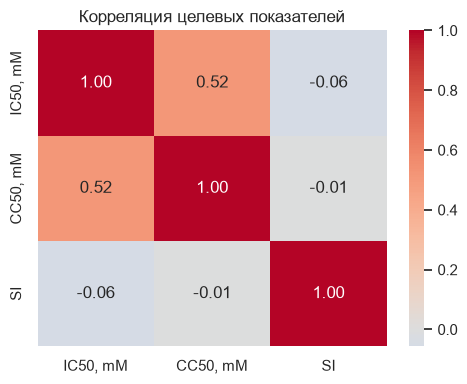

          IC50, mM  CC50, mM        SI
IC50, mM  1.000000  0.516589 -0.057035
CC50, mM  0.516589  1.000000 -0.006169
SI       -0.057035 -0.006169  1.000000
График сохранен: /Users/dmitrijgoncarov/mephi_masters/sem_2/classic_ML/coursework/drug_activity_prediction_variant/notebooks/results/figures/eda_target_correlation.png


In [9]:
# Корреляция между целевыми показателями

target_correlation = dataset[target_columns].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(target_correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Корреляция целевых показателей")
plt.tight_layout()
correlation_path = figures_dir / "eda_target_correlation.png"
plt.savefig(correlation_path, dpi=160)
plt.show()

print(target_correlation)
print("График сохранен:", correlation_path)


## Тепловая карта корреляций\n\nТепловая карта построена не по всем дескрипторам, а по целевым переменным и 20 признакам с наибольшей абсолютной корреляцией с целями. Такой формат сохраняет читаемость графика и позволяет увидеть как связи с целями, так и взаимную коррелированность наиболее заметных признаков.

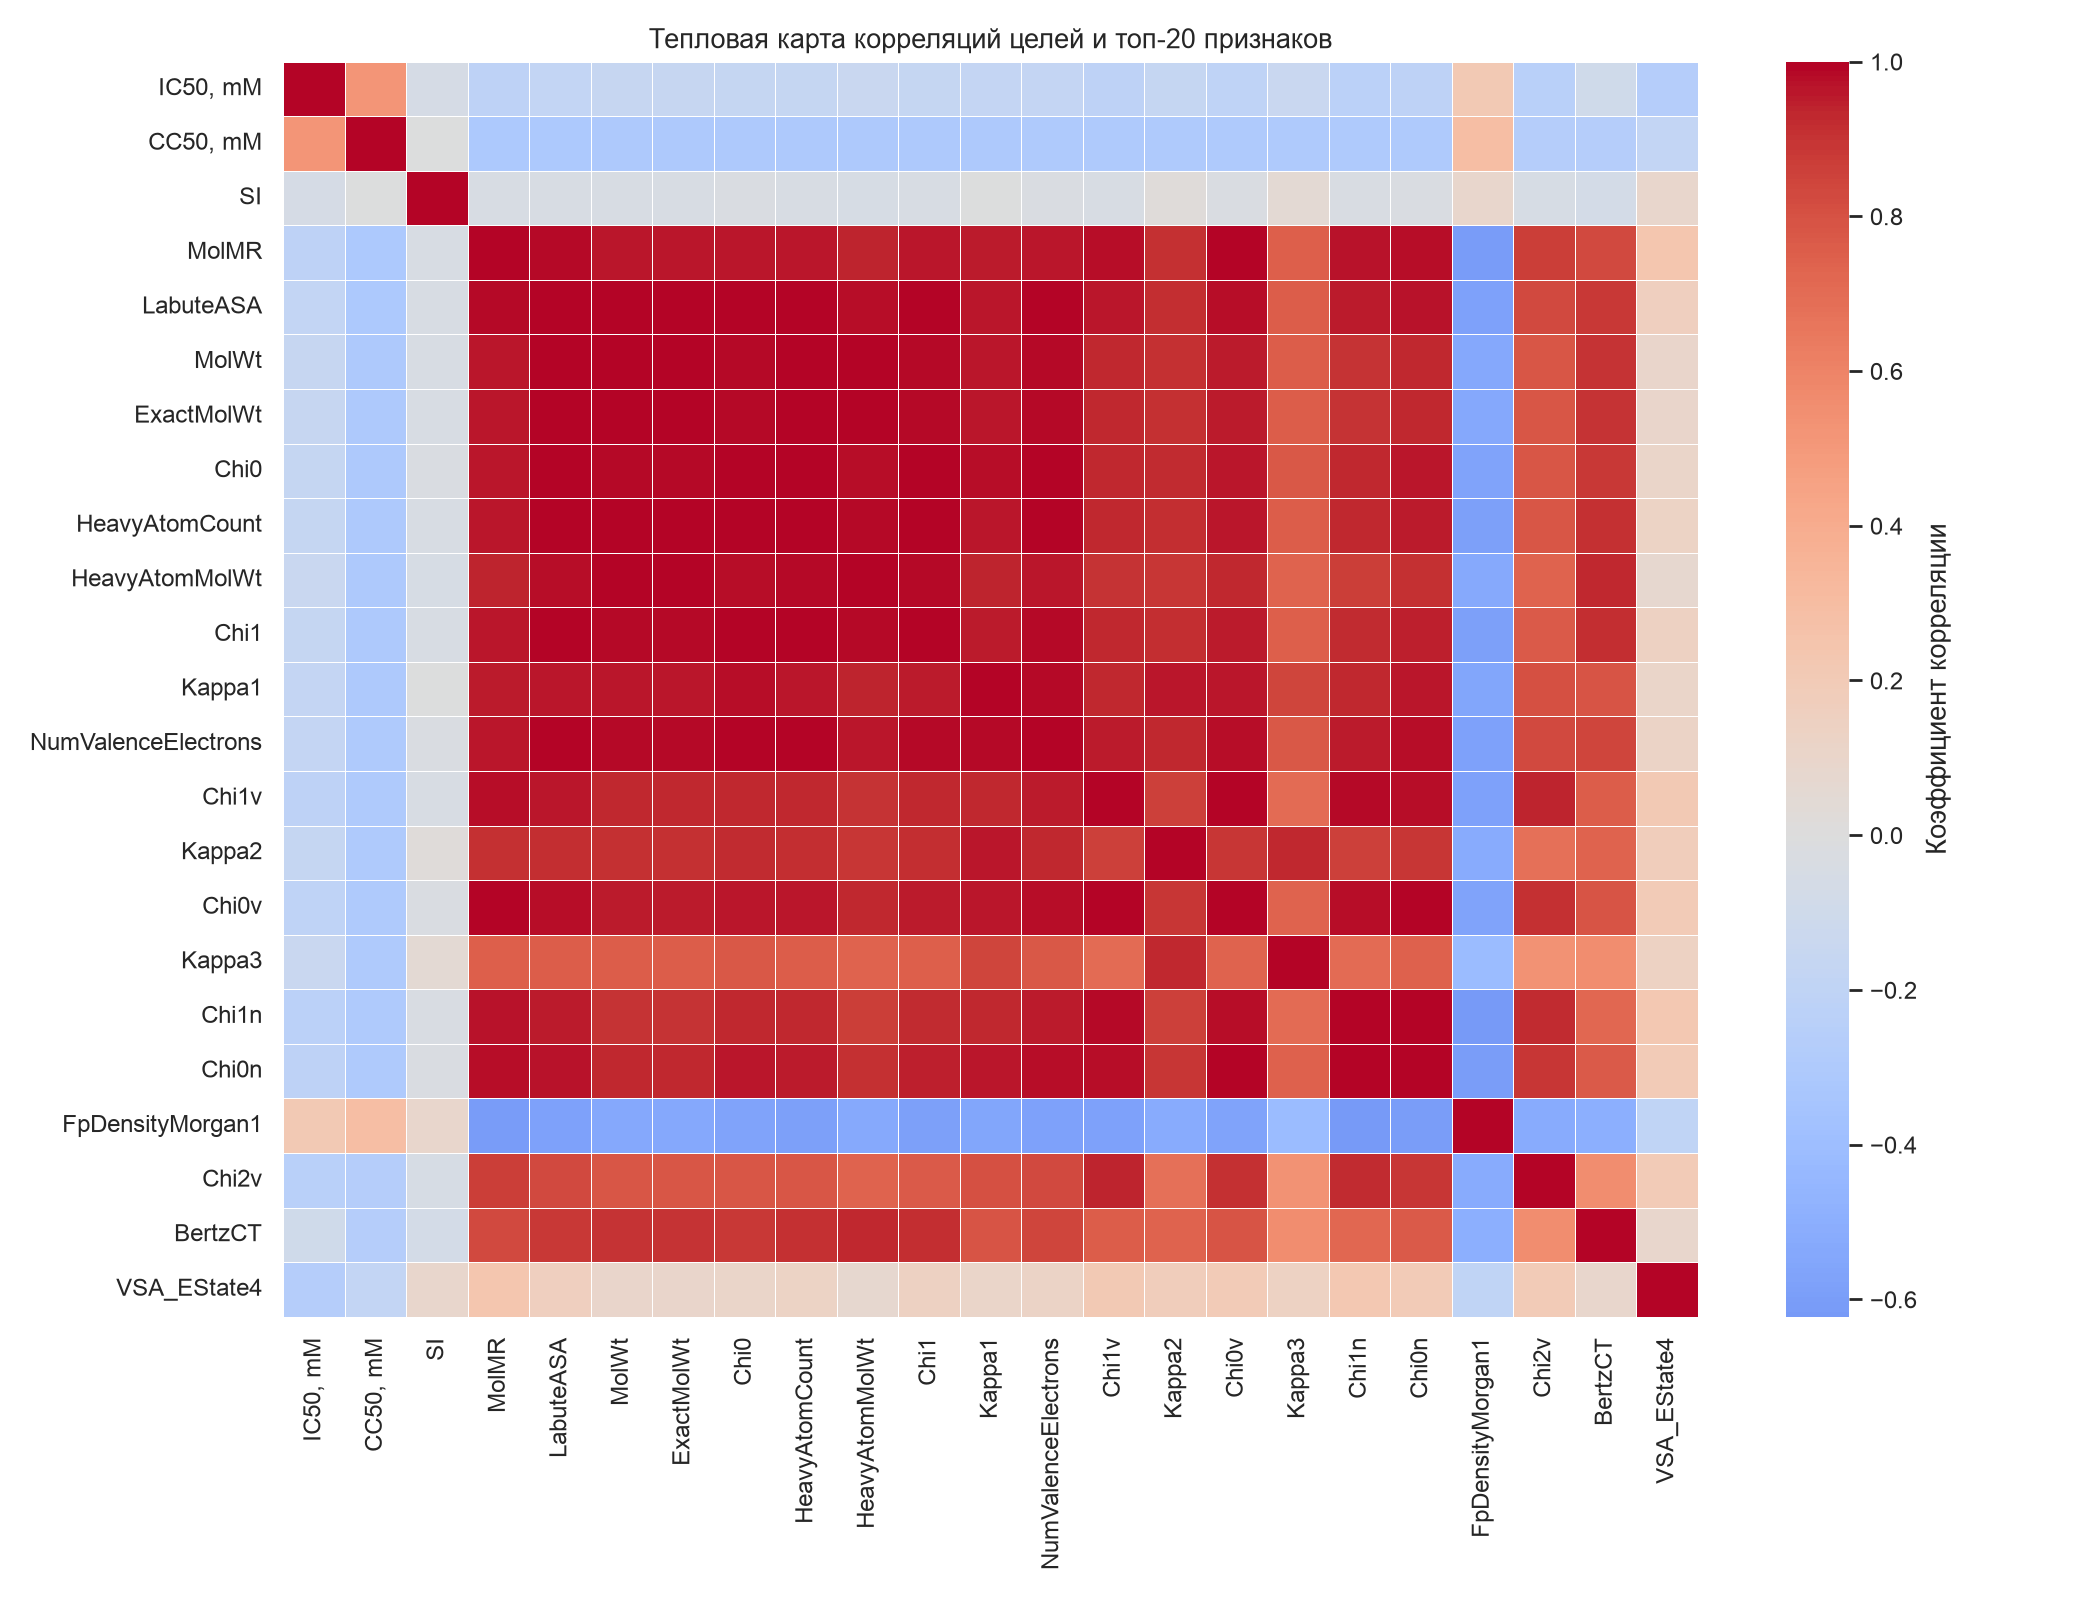

In [ ]:
# Тепловая карта корреляций для целей и наиболее связанных признаков

feature_columns = [column for column in dataset.columns if column not in target_columns]
correlations = dataset[feature_columns + target_columns].corr(numeric_only=True)
target_correlations = correlations[target_columns].drop(index=target_columns, errors="ignore")
top_features = target_correlations.abs().max(axis=1).sort_values(ascending=False).head(20).index.tolist()

heatmap_data = dataset[target_columns + top_features].corr(numeric_only=True)

plt.figure(figsize=(13, 10))
sns.heatmap(
    heatmap_data,
    cmap="coolwarm",
    center=0,
    linewidths=0.3,
    linecolor="white",
    square=False,
    cbar_kws={"label": "Коэффициент корреляции"},
)
plt.title("Тепловая карта корреляций целей и топ-20 признаков")
plt.tight_layout()
heatmap_path = figures_dir / "eda_top_feature_correlation_heatmap.png"
plt.savefig(heatmap_path, dpi=160)
plt.show()

print("График сохранен:", heatmap_path)

На карте видно, что часть топ-признаков связана между собой сильнее, чем с целевыми переменными. Это подтверждает наличие мультиколлинеарности и объясняет, почему в моделях используется отбор признаков. Связи с SI слабее, чем с IC50 и CC50, поэтому для SI ожидаемо сложнее получить устойчивую регрессионную модель.

Между IC50 и CC50 наблюдается умеренная положительная корреляция.
Корреляция SI с IC50 и CC50 близка к нулю, что объясняется нелинейной природой SI и сильным влиянием экстремальных значений.
Из-за этого SI является наиболее сложной целевой переменной для прямой регрессии.

In [10]:
# Поиск признаков, наиболее связанных с каждой целевой переменной

full_correlation = dataset.corr(numeric_only=True)

for target_column in target_columns:
    top_features = (
        full_correlation[target_column]
        .drop(index=target_columns, errors="ignore")
        .dropna()
        .abs()
        .sort_values(ascending=False)
        .head(15)
    )

    print(f"Топ-15 признаков по абсолютной корреляции с {target_column}")
    print(top_features.to_frame("abs_correlation"))


Топ-15 признаков по абсолютной корреляции с IC50, mM
                  abs_correlation
VSA_EState4              0.264838
Chi2n                    0.252477
PEOE_VSA7                0.249386
Chi2v                    0.244996
Chi4v                    0.238554
Chi4n                    0.237804
Chi3n                    0.233881
Chi3v                    0.232502
SlogP_VSA5               0.230400
MolLogP                  0.225549
Chi1n                    0.224332
fr_nitro                 0.223239
FpDensityMorgan1         0.215285
BCUT2D_LOGPHI            0.215042
Chi1v                    0.214567
Топ-15 признаков по абсолютной корреляции с CC50, mM
                     abs_correlation
MolMR                       0.312279
LabuteASA                   0.312227
MolWt                       0.310567
ExactMolWt                  0.310507
Chi0                        0.309054
HeavyAtomCount              0.308748
HeavyAtomMolWt              0.307811
Chi1                        0.307269
Kappa1           

Отдельные признаки имеют умеренную связь с IC50 и CC50, но сильных линейных корреляций с целевыми показателями не наблюдается.
Это указывает на необходимость нелинейных моделей: деревьев решений, ансамблей и градиентного бустинга.
Для SI линейные связи особенно слабые, поэтому качество моделей для этой цели ожидаемо ниже.